In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

#PHASE 1 DATA CLEANING

df = pd.read_csv("/content/Student Depression Dataset.csv")

# Keep only students
df = df[df['Profession'] == 'Student']

# Delete bad cities
df = df[~df['City'].isin(['Less than 5 Kalyan', 'Saanvi', 'Harsha', '3.0'])]

# Remove missing ages
df = df.dropna(subset=['Age'])

# Remove impossible ages
df = df[(df['Age'] >= 15) & (df['Age'] <= 100)]

# Remove impossible CGPA
df = df[df['CGPA'] > 0]
df = df[df['CGPA'] <= 10]

print(f"Clean dataset has {len(df)} rows")
print(df.head())



Clean dataset has 27855 rows
   id  Gender   Age           City Profession  Academic Pressure  \
0   2    Male  33.0  Visakhapatnam    Student                5.0   
1   8  Female  24.0      Bangalore    Student                2.0   
2  26    Male  31.0       Srinagar    Student                3.0   
3  30  Female  28.0       Varanasi    Student                3.0   
4  32  Female  25.0         Jaipur    Student                4.0   

   Work Pressure  CGPA  Study Satisfaction  Job Satisfaction  \
0            0.0  8.97                 2.0               0.0   
1            0.0  5.90                 5.0               0.0   
2            0.0  7.03                 5.0               0.0   
3            0.0  5.59                 2.0               0.0   
4            0.0  8.13                 3.0               0.0   

      Sleep Duration Dietary Habits   Degree  \
0          5-6 hours        Healthy  B.Pharm   
1          5-6 hours       Moderate      BSc   
2  Less than 5 hours        Healt

In [ ]:

Q1: Do students with suicidal thoughts have higher depression rates?

Q2: Does sleep duration affect depression?

Q3: Is there a relationship between CGPA and depression?

Q4: Does academic pressure lead to depression?

Q5: Does financial stress contribute to depression?

Q6: Do students who study/work more hours tend to be more depressed?

Object `rates` not found.
Object `depression` not found.
Object `depression` not found.
Object `depression` not found.


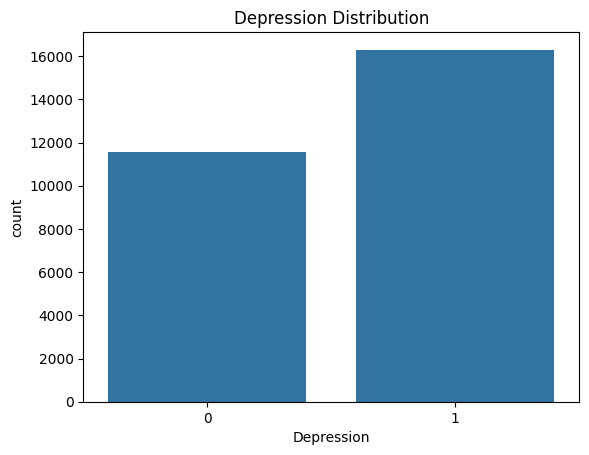

In [ ]:
#How many depressed and not depressed students
df['Depression'].value_counts()
sns.countplot(x='Depression', data=df)
plt.title ('Depression Distribution')
plt.show()

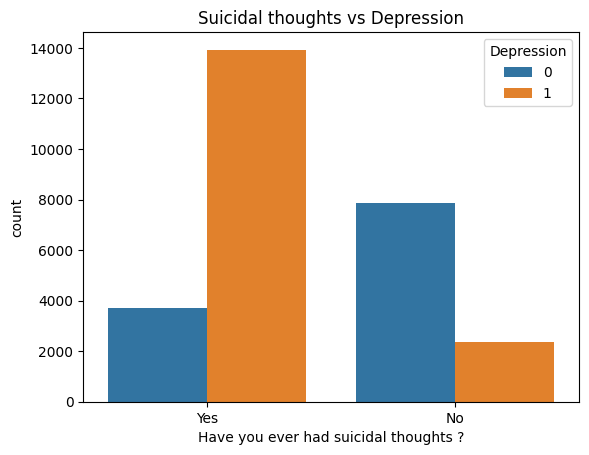

In [ ]:
#relation detween suicidal thoughts and higher depression rates
pd.crosstab(df['Have you ever had suicidal thoughts ?'], df['Depression'])
#bar plot
sns.countplot(x='Have you ever had suicidal thoughts ?', hue='Depression', data=df)
plt.title('Suicidal thoughts vs Depression')
plt.show()

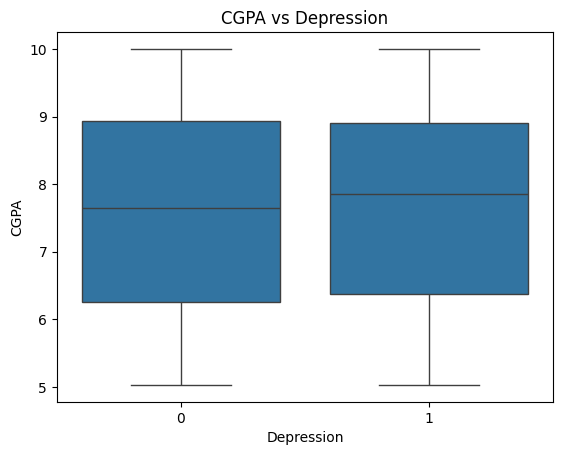

In [ ]:
#CGPA vs Depression
sns.boxplot(x='Depression', y='CGPA', data= df)
plt.title('CGPA vs Depression')
plt.show()

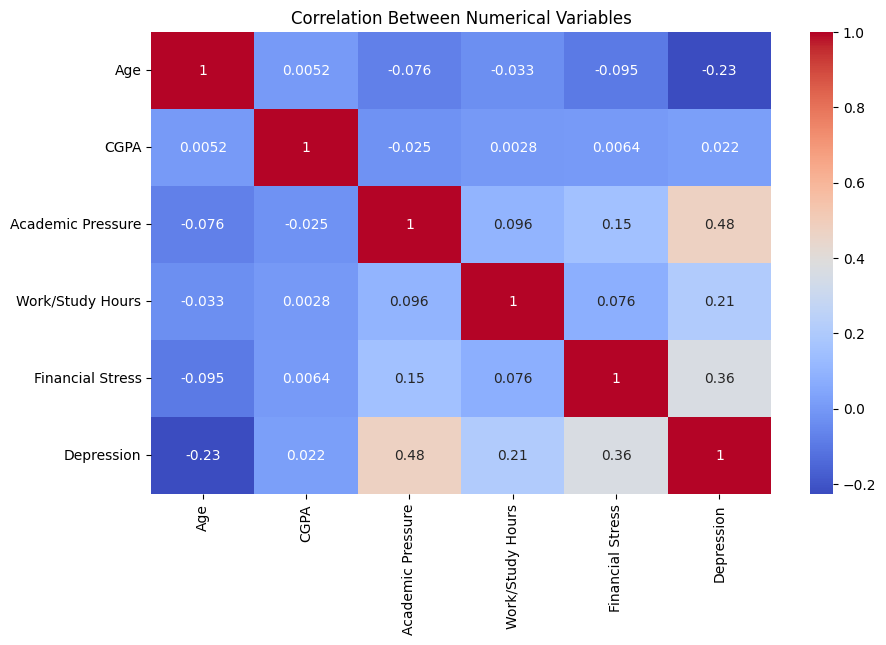

In [ ]:
#coorelation heatmap
numeric_cols = ['Age', 'CGPA', 'Academic Pressure', 'Work/Study Hours', 'Financial Stress', 'Depression']
plt.figure(figsize=(10,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Between Numerical Variables')
plt.show()

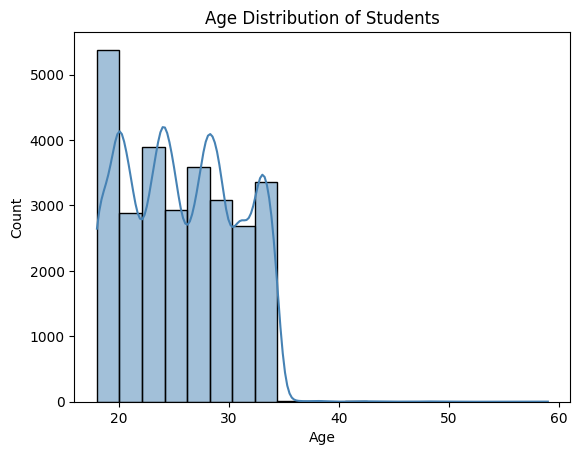

count    27855.000000
mean        25.820643
std          4.905922
min         18.000000
25%         21.000000
50%         25.000000
75%         30.000000
max         59.000000
Name: Age, dtype: float64


In [ ]:
#Age Distribution (Histogram)
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(df['Age'], bins=20, kde=True, color='steelblue')
plt.title('Age Distribution of Students')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

print(df['Age'].describe())

/tmp/ipykernel_1879/3680266903.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Depression', y='Academic Pressure', data=df,


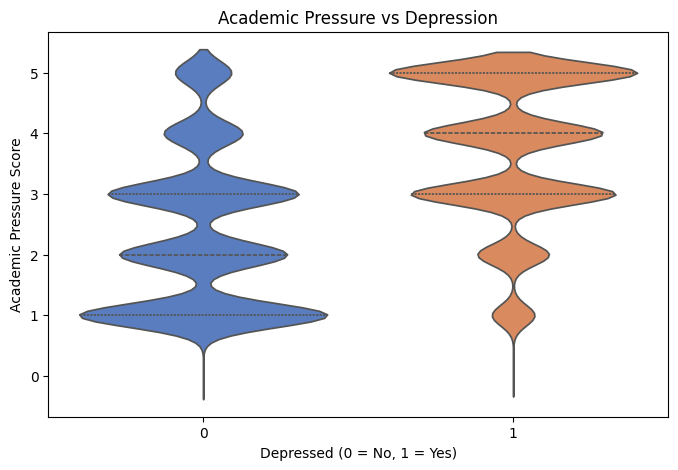

              count      mean       std  min  25%  50%  75%  max
Depression                                                      
0           11555.0  2.362267  1.252574  0.0  1.0  2.0  3.0  5.0
1           16300.0  3.693742  1.188198  0.0  3.0  4.0  5.0  5.0


In [ ]:
#Academic Pressure vs Depression (Violin Plot)
plt.figure(figsize=(8, 5))
sns.violinplot(x='Depression', y='Academic Pressure', data=df,
               palette='muted', inner='quartile')
plt.title('Academic Pressure vs Depression')
plt.xlabel('Depressed (0 = No, 1 = Yes)')
plt.ylabel('Academic Pressure Score')
plt.show()

print(df.groupby('Depression')['Academic Pressure'].describe())

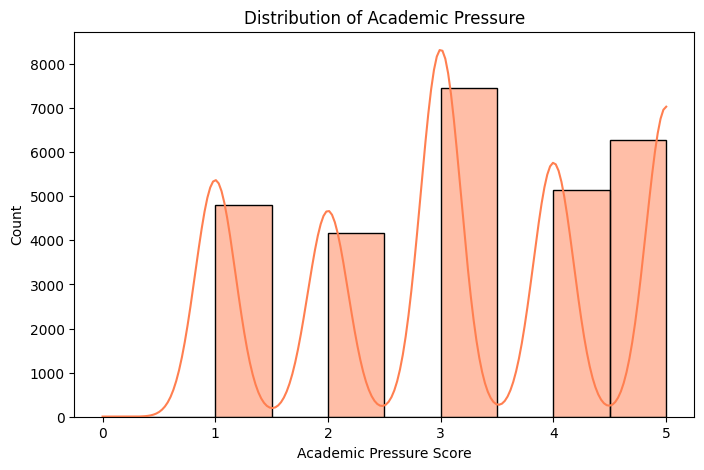

count    27855.000000
mean         3.141411
std          1.381051
min          0.000000
25%          2.000000
50%          3.000000
75%          4.000000
max          5.000000
Name: Academic Pressure, dtype: float64


In [ ]:
#Academic Pressure Distribution (Histogram)
plt.figure(figsize=(8, 5))
sns.histplot(df['Academic Pressure'], bins=10, kde=True, color='coral')
plt.title('Distribution of Academic Pressure')
plt.xlabel('Academic Pressure Score')
plt.ylabel('Count')
plt.show()

print(df['Academic Pressure'].describe())

/tmp/ipykernel_1879/1568314388.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sleep Duration', data=df, order=sleep_order, palette='pastel')


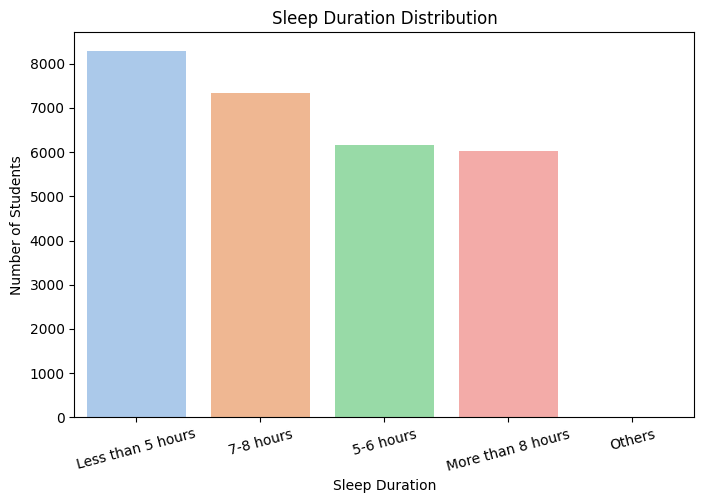

Sleep Duration
Less than 5 hours    8297
7-8 hours            7334
5-6 hours            6173
More than 8 hours    6033
Others                 18
Name: count, dtype: int64


In [ ]:
# Sleep Duration Distribution (Count Plot)
plt.figure(figsize=(8, 5))
sleep_order = df['Sleep Duration'].value_counts().index
sns.countplot(x='Sleep Duration', data=df, order=sleep_order, palette='pastel')
plt.title('Sleep Duration Distribution')
plt.xlabel('Sleep Duration')
plt.ylabel('Number of Students')
plt.xticks(rotation=15)
plt.show()

print(df['Sleep Duration'].value_counts())

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score
import joblib

# Feature Engineering
df['Total_Stress'] = df['Academic Pressure'] + df['Financial Stress']

# Label Encoding
le = LabelEncoder()
df['Gender_encoded'] = le.fit_transform(df['Gender'])

# Define features (X) and target (y)
# Selecting relevant numerical columns and newly engineered/encoded features
X = df[['Age', 'CGPA', 'Academic Pressure', 'Work/Study Hours', 'Financial Stress', 'Total_Stress', 'Gender_encoded']]
y = df['Depression']

# Impute missing values in X with the mean of each column
X = X.fillna(X.mean())

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Logistic Regression
model1 = LogisticRegression(max_iter=1000)
model1.fit(X_train, y_train)
y_pred1 = model1.predict(X_test)

# Decision Tree
model2 = DecisionTreeClassifier(random_state=42)
model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)

# Random Forest
model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train, y_train)
y_pred3 = model3.predict(X_test)

# Evaluation Metrics (imports moved to top)

# Grid Search
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10]
}
grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid,
                    cv=5,  # 5-fold cross validation
                    scoring='recall')

# Fit GridSearchCV (assuming X_train, y_train from earlier split)
grid.fit(X_train, y_train)
best_model = grid.best_estimator_

# joblib for saving python objects to files
joblib.dump(best_model, 'depression_model.pkl')



# Make predictions
y_pred1 = model1.predict(X_test)
y_pred2 = model2.predict(X_test)
y_pred3 = model3.predict(X_test)
y_pred_best = best_model.predict(X_test)

# Print results
print("=" * 50)
print("LOGISTIC REGRESSION")
print(f"Precision: {precision_score(y_test, y_pred1):.3f}")
print(f"Recall: {recall_score(y_test, y_pred1):.3f}")

print("\nDECISION TREE")
print(f"Precision: {precision_score(y_test, y_pred2):.3f}")
print(f"Recall: {recall_score(y_test, y_pred2):.3f}")

print("\nRANDOM FOREST")
print(f"Precision: {precision_score(y_test, y_pred3):.3f}")
print(f"Recall: {recall_score(y_test, y_pred3):.3f}")

print("\nTUNED RANDOM FOREST")
print(f"Precision: {precision_score(y_test, y_pred_best):.3f}")
print(f"Recall: {recall_score(y_test, y_pred_best):.3f}")

print("\nBest Parameters:", grid.best_params_)
print("Model saved as 'depression_model.pkl'")

LOGISTIC REGRESSION
Precision: 0.798
Recall: 0.837

DECISION TREE
Precision: 0.740
Recall: 0.744

RANDOM FOREST
Precision: 0.781
Recall: 0.811

TUNED RANDOM FOREST
Precision: 0.790
Recall: 0.846

Best Parameters: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}
Model saved as 'depression_model.pkl'


In [ ]:
from google.colab import files
files.download('depression_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

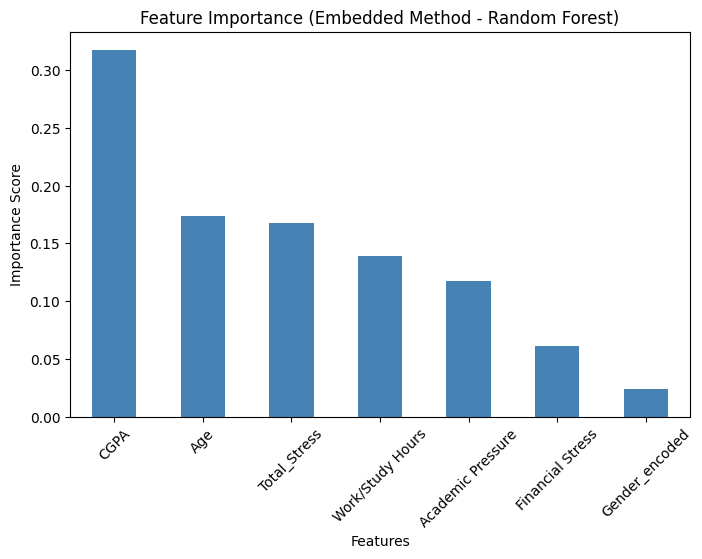

CGPA                 0.317034
Age                  0.173537
Total_Stress         0.167512
Work/Study Hours     0.138964
Academic Pressure    0.117672
Financial Stress     0.061154
Gender_encoded       0.024127
dtype: float64


In [ ]:
#Feature Selection
#Feature Importance from Random Forest

# Get feature importance scores from the trained model
feature_importance = pd.Series(model3.feature_importances_, index=X.columns)
# Plot
plt.figure(figsize=(8, 5))
feature_importance.plot(kind='bar', color='steelblue')
plt.title('Feature Importance (Embedded Method - Random Forest)')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=45)
plt.show()

print(feature_importance)

What is Validation?

Validation is the process of testing our model on data it has never seen before, to check how well it will perform in real life.

In this project, I split the data into two parts:

Training set (80%) — the model learns from this
Test set (20%) — we use this to validate how good the model i

I also used Cross Validation (cv=5) inside GridSearchCV, which means the training data is split into 5 parts, and the model is trained and tested 5 times on different parts. This gives a more reliable measure of performance.

Why is it important?

Without validation, the model might just memorize the training data and fail on new data. This is called overfitting. Validation protects us from this problem and tells us if our model is actually useful in real life.




What is Parameter Tuning and Why is it Important?

What is Parameter Tuning?

Every machine learning algorithm has settings called hyperparameters that control how it learns. For example, in Random Forest:

n_estimators — how many trees to build
max_depth — how deep each tree can grow
min_samples_split — minimum samples needed to split a node


Parameter tuning means finding the best combination of these settings to get the best model performance.

In this project I used GridSearchCV which automatically tries every possible combination and picks the best one.

Why is it important?

The default settings of any algorithm are not always the best for your specific data. Tuning the parameters can significantly improve the model's accuracy, precision, and recall. Without tuning, we might be leaving performance on the table.